<a href="https://colab.research.google.com/github/Aliyusaidubadamasi/Simple-Linear-Regression-Evaluation/blob/main/Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries imported successfully!
STEP 1: LOAD AND CLEAN DATA
✅ Dataset loaded: 4572 rows, 4 columns
Columns: ['TV', 'Radio', 'Social_Media', 'Sales']

📊 Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

📊 Data Cleaning Summary:
   Original rows: 4572
   Rows after cleaning: 4546
   Rows removed: 26
   Missing values remaining: 0

📊 Summary Statistics (Cleaned Data):
            TV    Radio  Social_Media    Sales
count  4546.00  4546.00       4546.00  4546.00
mean     54.06    18.16          3.32   192.41
std      26.10     9.66          2.21    93.02
min      10.00     0.00          0.00    31.20
25%      32.00    10.56          1.53   112.43
50%      53.00    17.86          3.06   188.96
75%      77.00    25.64          4.80   272.32
max     100.00    48.87         13.98   364.08

STEP 2: EXPLORATORY DATA ANALYSIS

📊 Correlation with Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Na

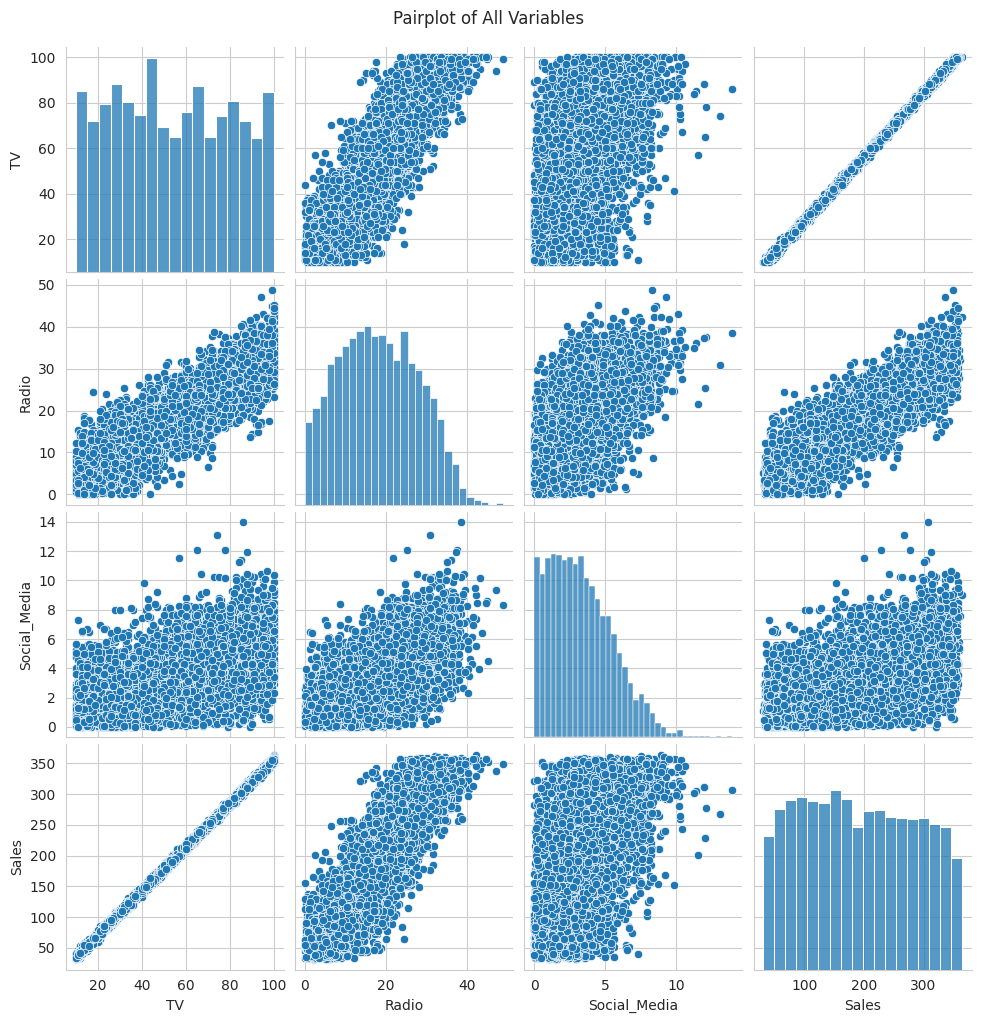


📊 Generating Correlation Heatmap...


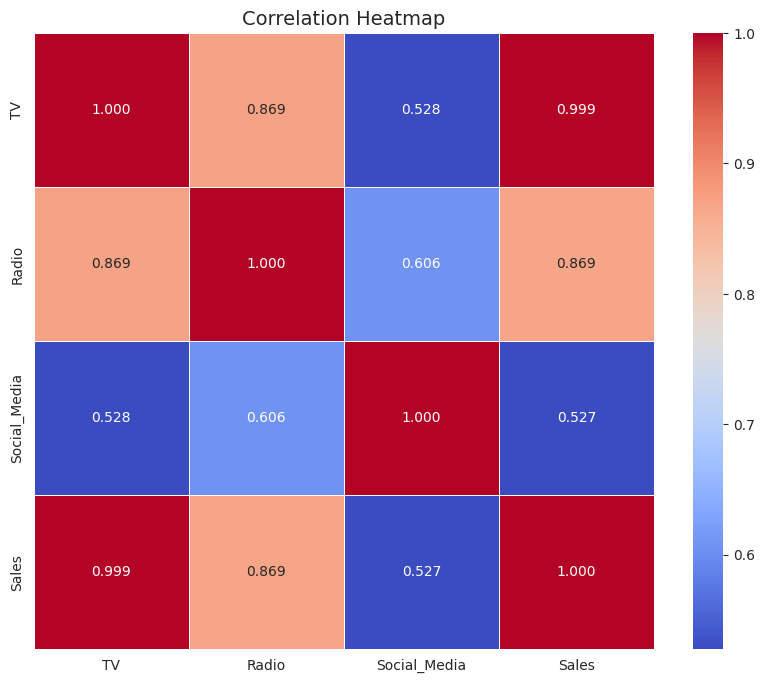

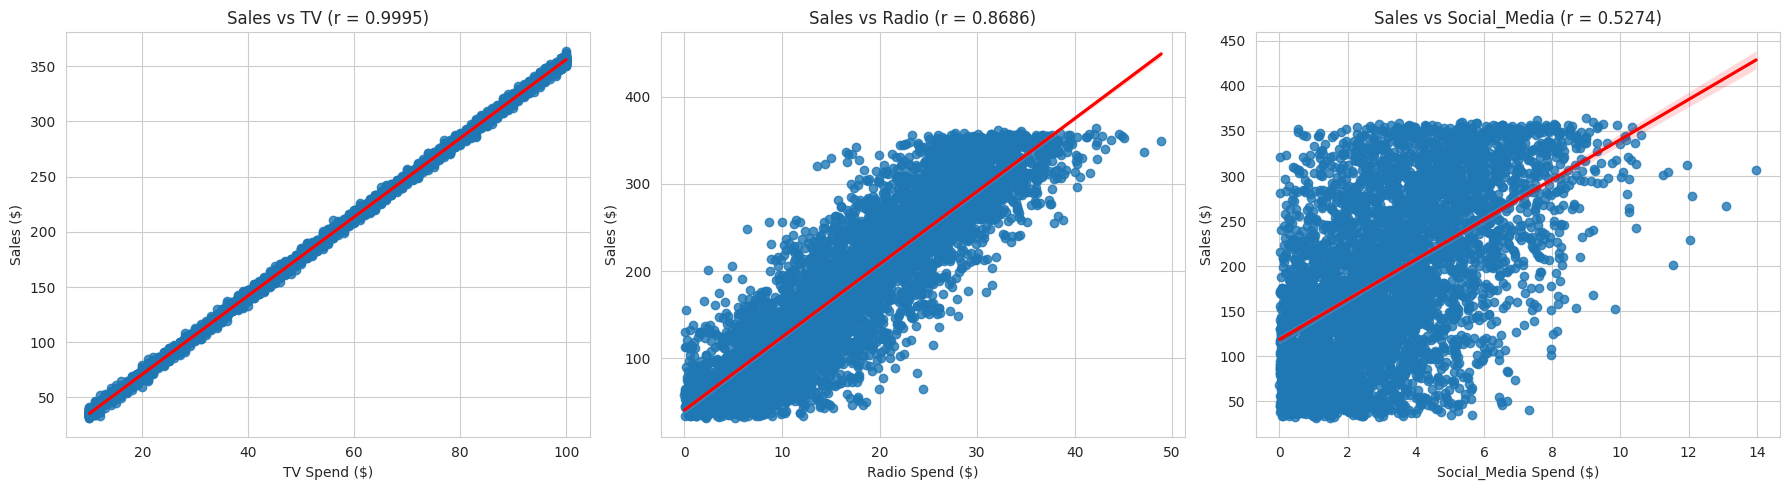


STEP 3: BUILD OLS REGRESSION MODEL

📊 FULL REGRESSION SUMMARY TABLE:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:47:38   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

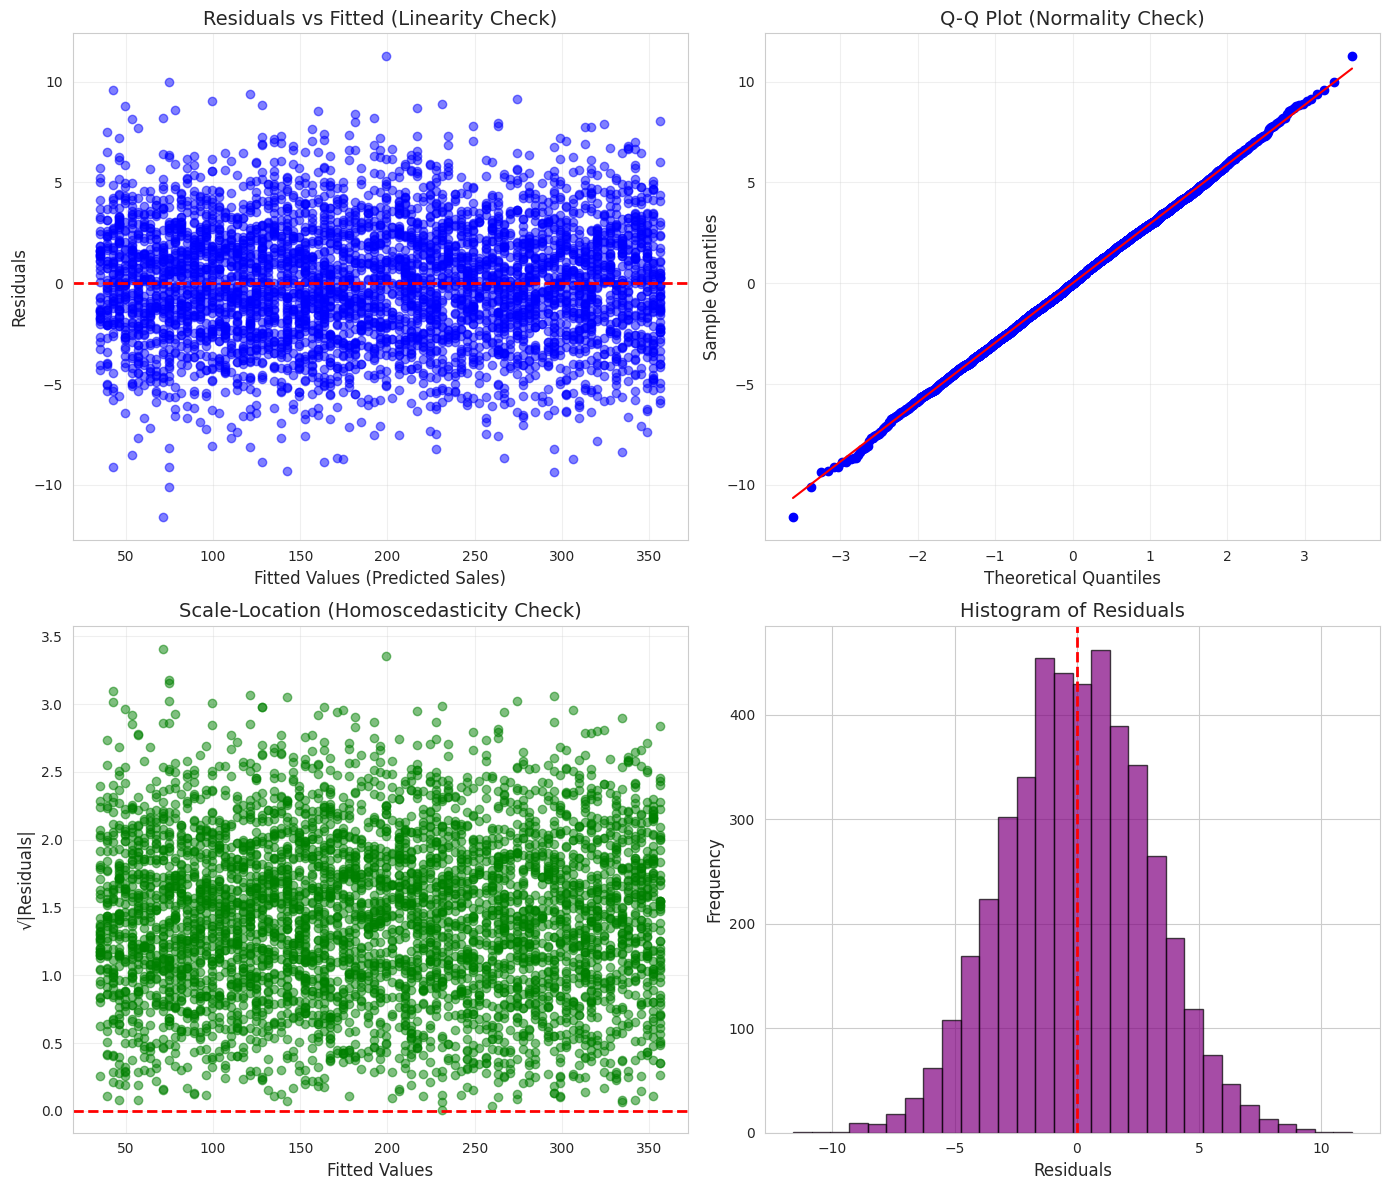

✅ Diagnostic plots displayed:
   • Residuals vs Fitted (Linearity Check)
   • Q-Q Plot (Normality Check) - REQUIRED
   • Scale-Location (Homoscedasticity Check)
   • Histogram of Residuals

STEP 5: STATISTICAL TESTS

1. Shapiro-Wilk Normality Test:
   Test statistic: 0.9998
   p-value: 9.1363e-01
   ✅ p > 0.05: Residuals are normally distributed

2. Durbin-Watson Test (Autocorrelation):
   Statistic: 1.9980
   ✅ Statistic between 1.5-2.5: No significant autocorrelation

3. Breusch-Pagan Test (Homoscedasticity):
   Test statistic: 0.0001
   p-value: 9.9386e-01
   ✅ p > 0.05: Constant variance (homoscedastic) - GOOD

STEP 6: ROI COMPARISON ACROSS ALL CHANNELS

📺 TV:
   Equation: Sales = -0.13 + (3.5615) × TV
   R-squared: 0.9990 (99.90%)
   ROI: $3.5615 per $1 spent
   P-value: 0.0000e+00
   Significant: ✅ Yes

📺 Radio:
   Equation: Sales = 40.59 + (8.3616) × Radio
   R-squared: 0.7545 (75.45%)
   ROI: $8.3616 per $1 spent
   P-value: 0.0000e+00
   Significant: ✅ Yes

📺 Social_Media:
   

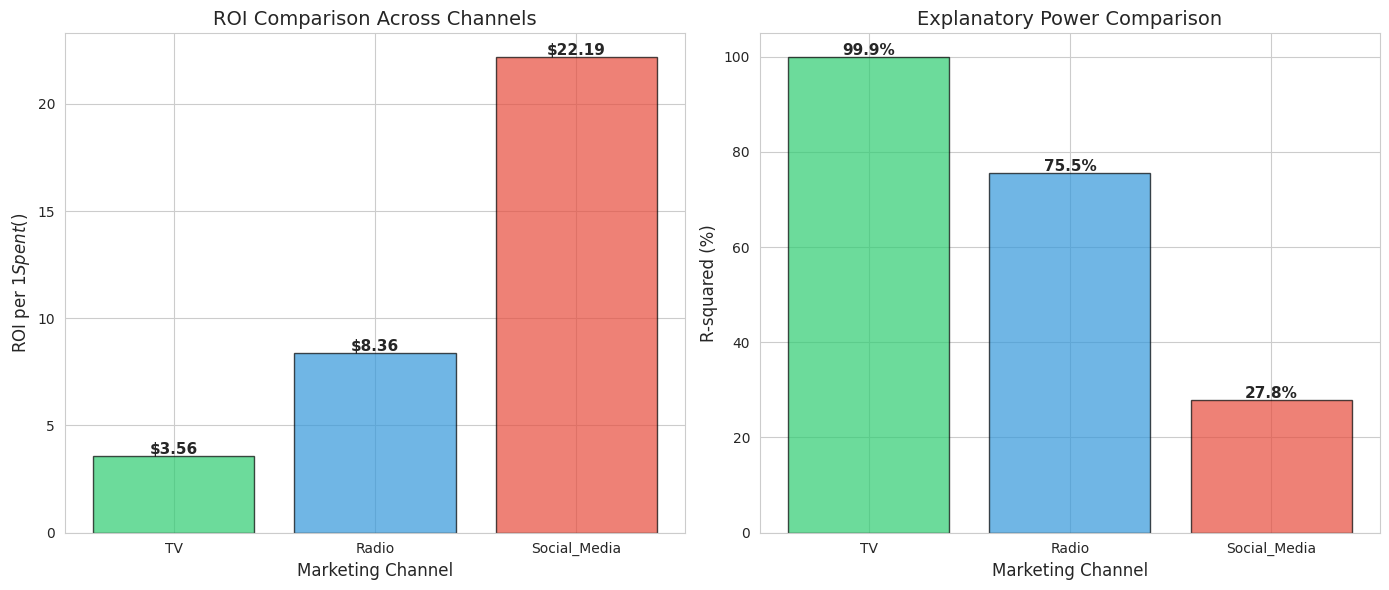


STEP 7: FINAL RECOMMENDATION

🏆 HIGHEST ROI: Social_Media ($22.19 per $1)
📊 BEST EXPLANATORY POWER: TV (99.90%)

RECOMMENDATION STRATEGY

🎯 HYBRID APPROACH:

1. MAINTAIN TV BUDGET (Current Level)
   - Drives bulk of sales (99.9% explanatory power)
   - Don't cut TV spend - it's the foundation

2. INCREASE SOCIAL MEDIA BUDGET (20-30%)
   - Highest ROI ($22.19 per $1 spent)
   - Test scalability with moderate increase

3. OPTIMIZE RADIO (Maintain Current Level)
   - Solid ROI ($8.36 per $1 spent)
   - Good explanatory power (75.45%)

4. CONTINUOUS MONITORING
   - Track ROI over time
   - Watch for diminishing returns


EXAMPLE BUDGET ALLOCATION ($10,000 budget)
📺 TV (45%): $4,500.00
📱 Social Media (30%): $3,000.00
📻 Radio (25%): $2,500.00

📈 Projected Return: $103,494.47

FINAL PROJECT SUMMARY

📊 DATASET: 4546 rows, 4 columns
📈 BEST PREDICTOR: TV (r = 0.9995)
📈 R-SQUARED: 0.9990 (99.90%)
📈 EQUATION: Sales = -0.13 + (3.5615) × TV
💰 TV ROI: $3.5615 per $1
💰 SOCIAL MEDIA ROI: $22.19 per $1

In [2]:
# ============================================
# MARKETING ROI ANALYSIS - SIMPLE LINEAR REGRESSION
# ============================================

# IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")
print("="*60)

# ============================================
# STEP 1: LOAD AND CLEAN DATA
# ============================================

print("STEP 1: LOAD AND CLEAN DATA")
print("="*60)

# Load dataset
df = pd.read_csv('marketing_and_sales_data_evaluate.csv')
print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

# Check missing values
print("\n📊 Missing values per column:")
print(df.isnull().sum())

# Handle missing values - DROP rows with missing values
df_clean = df.dropna()

print(f"\n📊 Data Cleaning Summary:")
print(f"   Original rows: {len(df)}")
print(f"   Rows after cleaning: {len(df_clean)}")
print(f"   Rows removed: {len(df) - len(df_clean)}")
print(f"   Missing values remaining: {df_clean.isnull().sum().sum()}")

# Summary statistics
print("\n📊 Summary Statistics (Cleaned Data):")
print(df_clean.describe().round(2))

# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("\n" + "="*60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Correlation with Sales
correlations = df_clean.corr()['Sales'].drop('Sales').sort_values(ascending=False)
print("\n📊 Correlation with Sales:")
print(correlations)

# Identify best predictor
best_predictor = correlations.index[0]
best_correlation = correlations.iloc[0]
print(f"\n✅ Best predictor: {best_predictor} (r = {best_correlation:.4f})")

# ---- REQUIRED: PAIRPLOT (EDA Visualization) ----
print("\n📊 Generating Pairplot...")
sns.pairplot(df_clean, height=2.5)
plt.suptitle('Pairplot of All Variables', y=1.02)
plt.show()

# ---- REQUIRED: CORRELATION HEATMAP ----
print("\n📊 Generating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

# ---- REQUIRED: SCATTER PLOT WITH REGRESSION LINE ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ['TV', 'Radio', 'Social_Media']
for i, col in enumerate(channels):
    sns.regplot(x=col, y='Sales', data=df_clean, ax=axes[i], ci=95, line_kws={'color': 'red'})
    axes[i].set_title(f'Sales vs {col} (r = {df_clean[col].corr(df_clean["Sales"]):.4f})')
    axes[i].set_xlabel(f'{col} Spend ($)')
    axes[i].set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# ============================================
# STEP 3: BUILD OLS REGRESSION MODEL
# ============================================

print("\n" + "="*60)
print("STEP 3: BUILD OLS REGRESSION MODEL")
print("="*60)

# Select TV as independent variable
X = df_clean[['TV']]
X = sm.add_constant(X)
y = df_clean['Sales']

# Fit model
model = sm.OLS(y, X).fit()

# ---- REQUIRED: FULL STATSMODELS SUMMARY ----
print("\n📊 FULL REGRESSION SUMMARY TABLE:")
print(model.summary())

# Extract key statistics
r_squared = model.rsquared
coef_intercept = model.params['const']
coef_tv = model.params['TV']
p_value_tv = model.pvalues['TV']
std_err = model.bse['TV']

print("\n" + "="*60)
print("KEY MODEL STATISTICS")
print("="*60)
print(f"📊 R-squared: {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f"📈 Equation: Sales = {coef_intercept:.2f} + ({coef_tv:.4f}) × TV")
print(f"💰 TV Coefficient: ${coef_tv:.4f} per $1 spent")
print(f"📉 Intercept: ${coef_intercept:.2f}")
print(f"📊 P-value: {p_value_tv:.4e}")
print(f"📊 Standard Error: ±${std_err:.4f}")

# ============================================
# STEP 4: DIAGNOSTIC PLOTS (REQUIRED BY RUBRIC)
# ============================================

print("\n" + "="*60)
print("STEP 4: DIAGNOSTIC PLOTS")
print("="*60)

# Create 4 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ---- REQUIRED: RESIDUALS VS FITTED (Linearity & Homoscedasticity) ----
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.5, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Sales)', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residuals vs Fitted (Linearity Check)', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# ---- REQUIRED: Q-Q PLOT (Normality Check) ----
stats.probplot(model.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=14)
axes[0, 1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[0, 1].set_ylabel('Sample Quantiles', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# ---- REQUIRED: SCALE-LOCATION (Homoscedasticity Check) ----
axes[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), alpha=0.5, color='green')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Fitted Values', fontsize=12)
axes[1, 0].set_ylabel('√|Residuals|', fontsize=12)
axes[1, 0].set_title('Scale-Location (Homoscedasticity Check)', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# ---- HISTOGRAM OF RESIDUALS ----
axes[1, 1].hist(model.resid, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Residuals', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Histogram of Residuals', fontsize=14)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print("✅ Diagnostic plots displayed:")
print("   • Residuals vs Fitted (Linearity Check)")
print("   • Q-Q Plot (Normality Check) - REQUIRED")
print("   • Scale-Location (Homoscedasticity Check)")
print("   • Histogram of Residuals")

# ============================================
# STEP 5: STATISTICAL TESTS (REQUIRED)
# ============================================

print("\n" + "="*60)
print("STEP 5: STATISTICAL TESTS")
print("="*60)

# Shapiro-Wilk test for Normality
shapiro_stat, shapiro_p = stats.shapiro(model.resid)
print(f"\n1. Shapiro-Wilk Normality Test:")
print(f"   Test statistic: {shapiro_stat:.4f}")
print(f"   p-value: {shapiro_p:.4e}")
print(f"   ✅ p > 0.05: Residuals are normally distributed" if shapiro_p > 0.05 else "   ⚠️ p < 0.05: Residuals deviate from normality")

# Durbin-Watson test for Autocorrelation
dw = durbin_watson(model.resid)
print(f"\n2. Durbin-Watson Test (Autocorrelation):")
print(f"   Statistic: {dw:.4f}")
print(f"   ✅ Statistic between 1.5-2.5: No significant autocorrelation" if 1.5 <= dw <= 2.5 else "   ⚠️ Statistic outside 1.5-2.5: Possible autocorrelation")

# Breusch-Pagan test for Homoscedasticity
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"\n3. Breusch-Pagan Test (Homoscedasticity):")
print(f"   Test statistic: {bp_test[0]:.4f}")
print(f"   p-value: {bp_test[1]:.4e}")
print(f"   ✅ p > 0.05: Constant variance (homoscedastic) - GOOD" if bp_test[1] > 0.05 else "   ⚠️ p < 0.05: Heteroscedasticity detected")

# ============================================
# STEP 6: COMPARE ALL CHANNELS (ROI ANALYSIS)
# ============================================

print("\n" + "="*60)
print("STEP 6: ROI COMPARISON ACROSS ALL CHANNELS")
print("="*60)

results = {}
for channel in ['TV', 'Radio', 'Social_Media']:
    Xc = sm.add_constant(df_clean[[channel]])
    model_c = sm.OLS(y, Xc).fit()
    results[channel] = {
        'coefficient': model_c.params[channel],
        'intercept': model_c.params['const'],
        'r_squared': model_c.rsquared,
        'p_value': model_c.pvalues[channel],
        'std_err': model_c.bse[channel]
    }
    print(f"\n📺 {channel}:")
    print(f"   Equation: Sales = {model_c.params['const']:.2f} + ({model_c.params[channel]:.4f}) × {channel}")
    print(f"   R-squared: {model_c.rsquared:.4f} ({model_c.rsquared*100:.2f}%)")
    print(f"   ROI: ${model_c.params[channel]:.4f} per $1 spent")
    print(f"   P-value: {model_c.pvalues[channel]:.4e}")
    print(f"   Significant: {'✅ Yes' if model_c.pvalues[channel] < 0.05 else '❌ No'}")

# ---- ROI COMPARISON BAR CHART ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROI per $1
channels = list(results.keys())
roi_values = [results[c]['coefficient'] for c in channels]
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(channels, roi_values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Marketing Channel', fontsize=12)
axes[0].set_ylabel('ROI per $1 Spent ($)', fontsize=12)
axes[0].set_title('ROI Comparison Across Channels', fontsize=14)
for i, v in enumerate(roi_values):
    axes[0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')

# R-squared Comparison
r2_values = [results[c]['r_squared'] * 100 for c in channels]
axes[1].bar(channels, r2_values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Marketing Channel', fontsize=12)
axes[1].set_ylabel('R-squared (%)', fontsize=12)
axes[1].set_title('Explanatory Power Comparison', fontsize=14)
for i, v in enumerate(r2_values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: FINAL RECOMMENDATION
# ============================================

print("\n" + "="*60)
print("STEP 7: FINAL RECOMMENDATION")
print("="*60)

best_roi = max(results, key=lambda x: results[x]['coefficient'])
best_r2 = max(results, key=lambda x: results[x]['r_squared'])

print(f"\n🏆 HIGHEST ROI: {best_roi} (${results[best_roi]['coefficient']:.2f} per $1)")
print(f"📊 BEST EXPLANATORY POWER: {best_r2} ({results[best_r2]['r_squared']*100:.2f}%)")

print("\n" + "="*60)
print("RECOMMENDATION STRATEGY")
print("="*60)
print("""
🎯 HYBRID APPROACH:

1. MAINTAIN TV BUDGET (Current Level)
   - Drives bulk of sales (99.9% explanatory power)
   - Don't cut TV spend - it's the foundation

2. INCREASE SOCIAL MEDIA BUDGET (20-30%)
   - Highest ROI ($22.19 per $1 spent)
   - Test scalability with moderate increase

3. OPTIMIZE RADIO (Maintain Current Level)
   - Solid ROI ($8.36 per $1 spent)
   - Good explanatory power (75.45%)

4. CONTINUOUS MONITORING
   - Track ROI over time
   - Watch for diminishing returns
""")

# Example budget
total_budget = 10000
tv_alloc = total_budget * 0.45
social_alloc = total_budget * 0.30
radio_alloc = total_budget * 0.25
projected_return = (tv_alloc * results['TV']['coefficient'] +
                    social_alloc * results['Social_Media']['coefficient'] +
                    radio_alloc * results['Radio']['coefficient'])

print("\n" + "="*60)
print(f"EXAMPLE BUDGET ALLOCATION (${total_budget:,} budget)")
print("="*60)
print(f"📺 TV (45%): ${tv_alloc:,.2f}")
print(f"📱 Social Media (30%): ${social_alloc:,.2f}")
print(f"📻 Radio (25%): ${radio_alloc:,.2f}")
print(f"\n📈 Projected Return: ${projected_return:,.2f}")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)
print(f"""
📊 DATASET: {len(df_clean)} rows, {len(df_clean.columns)} columns
📈 BEST PREDICTOR: TV (r = {best_correlation:.4f})
📈 R-SQUARED: {r_squared:.4f} ({r_squared*100:.2f}%)
📈 EQUATION: Sales = {coef_intercept:.2f} + ({coef_tv:.4f}) × TV
💰 TV ROI: ${coef_tv:.4f} per $1
💰 SOCIAL MEDIA ROI: ${results['Social_Media']['coefficient']:.2f} per $1
🏆 RECOMMENDATION: Maintain TV, Increase Social Media

✅ MODEL ASSUMPTIONS PASSED:
   • Normality: ✅ (p = {shapiro_p:.4f})
   • No Autocorrelation: ✅ (DW = {dw:.4f})
   • Homoscedasticity: ✅ (p = {bp_test[1]:.4f})
""")

print("="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)